# Feature Engineering — Instacart Repurchase Model

## Objetivo

Construir un dataset de features de comportamiento por usuario 
a partir del historial de pedidos de Instacart. Este dataset 
es el insumo directo del modelo predictivo de recompra.

## Lógica general

- **Fuente de features**: `order_products__prior` + `orders` 
  (pedidos históricos de cada usuario).
- **Target**: `order_products__train` — el pedido más reciente 
  de cada usuario. Si ese pedido contiene al menos un producto 
  reordenado, el usuario es positivo (recompra = 1).
- **Unidad de análisis**: el usuario (`user_id`).

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

INSTACART_DIR = os.path.join('..', 'data', 'Instacart')
OUTPUTS_DIR   = os.path.join('..', 'outputs')

orders      = pd.read_csv(os.path.join(INSTACART_DIR, 'orders.csv'))
products    = pd.read_csv(os.path.join(INSTACART_DIR, 'products.csv'))
aisles      = pd.read_csv(os.path.join(INSTACART_DIR, 'aisles.csv'))
departments = pd.read_csv(os.path.join(INSTACART_DIR, 'departments.csv'))
prior       = pd.read_csv(os.path.join(INSTACART_DIR, 'order_products__prior.csv'))
train       = pd.read_csv(os.path.join(INSTACART_DIR, 'order_products__train.csv'))

for name, df in [('orders', orders), ('prior', prior), ('train', train)]:
    print(f"{name:<10} {df.shape}")

orders     (3421083, 7)
prior      (32434489, 4)
train      (1384617, 4)


---
## 1. Separación de conjuntos y construcción del target

El primer paso es separar los pedidos por `eval_set` y construir 
la variable target a nivel usuario. Un usuario es positivo si su 
pedido de train contiene al menos un producto reordenado.

In [2]:
orders_prior = orders[orders['eval_set'] == 'prior'].copy()
orders_train = orders[orders['eval_set'] == 'train'].copy()

target = (
    train.groupby('order_id')['reordered']
    .max()
    .reset_index()
    .rename(columns={'reordered': 'target'})
)

target = orders_train[['order_id', 'user_id']].merge(target, on='order_id')
target = target[['user_id', 'target']]

print(f"Usuarios en train:       {len(target):,}")
print(f"\nDistribución del target:")
print(target['target'].value_counts())
print(f"\nTasa de recompra: {target['target'].mean():.2%}")

Usuarios en train:       131,209

Distribución del target:
target
1    122607
0      8602
Name: count, dtype: int64

Tasa de recompra: 93.44%


### Redefinición del target

La definición original (al menos un producto reordenado) genera un 
target con 93.44% de positivos. Un modelo entrenado sobre este target 
no aprende patrones reales de comportamiento.

Se redefine el target como: la tasa de reorden del usuario en su pedido 
de train es mayor o igual a 0.5. Es decir, más de la mitad de los 
productos de ese pedido fueron comprados anteriormente. Esto distingue 
entre usuarios que exploran productos nuevos (target=0) y usuarios con 
comportamiento de compra repetitivo consolidado (target=1).

In [3]:
reorder_rate_train = (
    train.merge(orders_train[['order_id', 'user_id']], on='order_id')
    .groupby('user_id')['reordered']
    .mean()
    .reset_index()
    .rename(columns={'reordered': 'reorder_rate_train'})
)

target = reorder_rate_train.copy()
target['target'] = (target['reorder_rate_train'] >= 0.5).astype(int)

print(f"Usuarios en train: {len(target):,}")
print(f"\nDistribución del target:")
print(target['target'].value_counts())
print(f"\nTasa de recompra: {target['target'].mean():.2%}")
print(f"\nDistribución de reorder_rate_train:")
print(target['reorder_rate_train'].describe().round(3))

Usuarios en train: 131,209

Distribución del target:
target
1    87445
0    43764
Name: count, dtype: int64

Tasa de recompra: 66.65%

Distribución de reorder_rate_train:
count    131209.000
mean          0.602
std           0.307
min           0.000
25%           0.375
50%           0.632
75%           0.867
max           1.000
Name: reorder_rate_train, dtype: float64


---
## 2. Feature Engineering

Todas las features se construyen exclusivamente desde `order_products__prior` 
y `orders_prior`. No se usa ninguna información del pedido de train 
para evitar data leakage.

Las features capturan tres dimensiones del comportamiento del usuario:
- **Frecuencia y recencia**: con qué regularidad compra y cuándo fue su último pedido.
- **Diversidad**: variedad de productos y tamaño de carrito.
- **Lealtad**: proporción de productos que repite entre pedidos.

In [4]:
prior_orders = prior.merge(
    orders_prior[['order_id', 'user_id', 'order_number',
                  'order_dow', 'order_hour_of_day', 'days_since_prior_order']],
    on='order_id'
)

print(f"Shape prior_orders: {prior_orders.shape}")
print(f"\nColumnas disponibles:")
print(prior_orders.columns.tolist())
print(f"\nPrimeras filas:")
print(prior_orders.head(3))

Shape prior_orders: (32434489, 9)

Columnas disponibles:
['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']

Primeras filas:
   order_id  product_id  add_to_cart_order  reordered  user_id  order_number  \
0         2       33120                  1          1   202279             3   
1         2       28985                  2          1   202279             3   
2         2        9327                  3          0   202279             3   

   order_dow  order_hour_of_day  days_since_prior_order  
0          5                  9                     8.0  
1          5                  9                     8.0  
2          5                  9                     8.0  


### Construcción de features por usuario

Se calculan diez features agrupando por `user_id` sobre el historial 
completo de pedidos previos.

In [5]:
user_features = prior_orders.groupby('user_id').agg(
    total_orders        = ('order_number', 'max'),
    total_items         = ('product_id', 'count'),
    distinct_products   = ('product_id', 'nunique'),
    reorder_rate        = ('reordered', 'mean'),
    avg_days_between    = ('days_since_prior_order', 'mean'),
    std_days_between    = ('days_since_prior_order', 'std'),
    most_frequent_dow   = ('order_dow', lambda x: x.mode()[0]),
    most_frequent_hour  = ('order_hour_of_day', lambda x: x.mode()[0])
).reset_index()

user_features['avg_cart_size'] = (
    user_features['total_items'] / user_features['total_orders']
).round(2)

last_order = (
    orders_prior.sort_values('order_number')
    .groupby('user_id')['days_since_prior_order']
    .last()
    .reset_index()
    .rename(columns={'days_since_prior_order': 'days_since_last_order'})
)

user_features = user_features.merge(last_order, on='user_id')

print(f"Shape user_features: {user_features.shape}")
print(f"\nPrimeras filas:")
print(user_features.head(3).to_string(index=False))
print(f"\nNulos:")
print(user_features.isnull().sum())

Shape user_features: (206209, 11)

Primeras filas:
 user_id  total_orders  total_items  distinct_products  reorder_rate  avg_days_between  std_days_between  most_frequent_dow  most_frequent_hour  avg_cart_size  days_since_last_order
       1            10           59                 18      0.694915         20.259259          9.304463                  4                   7           5.90                   30.0
       2            14          195                102      0.476923         15.967033          9.119769                  2                   9          13.93                   13.0
       3            12           88                 33      0.625000         11.487179          4.869048                  0                  16           7.33                   15.0

Nulos:
user_id                  0
total_orders             0
total_items              0
distinct_products        0
reorder_rate             0
avg_days_between         0
std_days_between         0
most_frequent_dow       

### Construcción del dataset final

Se filtra `user_features` para conservar únicamente los usuarios 
presentes en el set de train. Los ~75.000 usuarios del set de test 
se excluyen por ausencia de ground truth.

In [6]:
df_model = user_features.merge(target[['user_id', 'target']], on='user_id')

print(f"Shape df_model: {df_model.shape}")
print(f"\nDistribución del target:")
print(df_model['target'].value_counts())
print(f"\nEstadísticas descriptivas:")
print(df_model.describe().round(2).to_string())

Shape df_model: (131209, 12)

Distribución del target:
target
1    87445
0    43764
Name: count, dtype: int64

Estadísticas descriptivas:
         user_id  total_orders  total_items  distinct_products  reorder_rate  avg_days_between  std_days_between  most_frequent_dow  most_frequent_hour  avg_cart_size  days_since_last_order     target
count  131209.00     131209.00    131209.00          131209.00     131209.00         131209.00         131209.00          131209.00           131209.00      131209.00              131209.00  131209.00
mean   103166.83         15.60       157.32              64.59          0.43             15.47              6.62               2.52               13.26           9.95                  16.08       0.67
std     59565.31         16.66       203.53              56.56          0.21              7.21              3.27               2.15                4.00           5.85                  10.44       0.47
min         1.00          3.00         3.00               

### Distribución de features clave por clase

Se visualizan las features con mayor potencial discriminatorio 
para anticipar si el modelo podrá separar las dos clases.

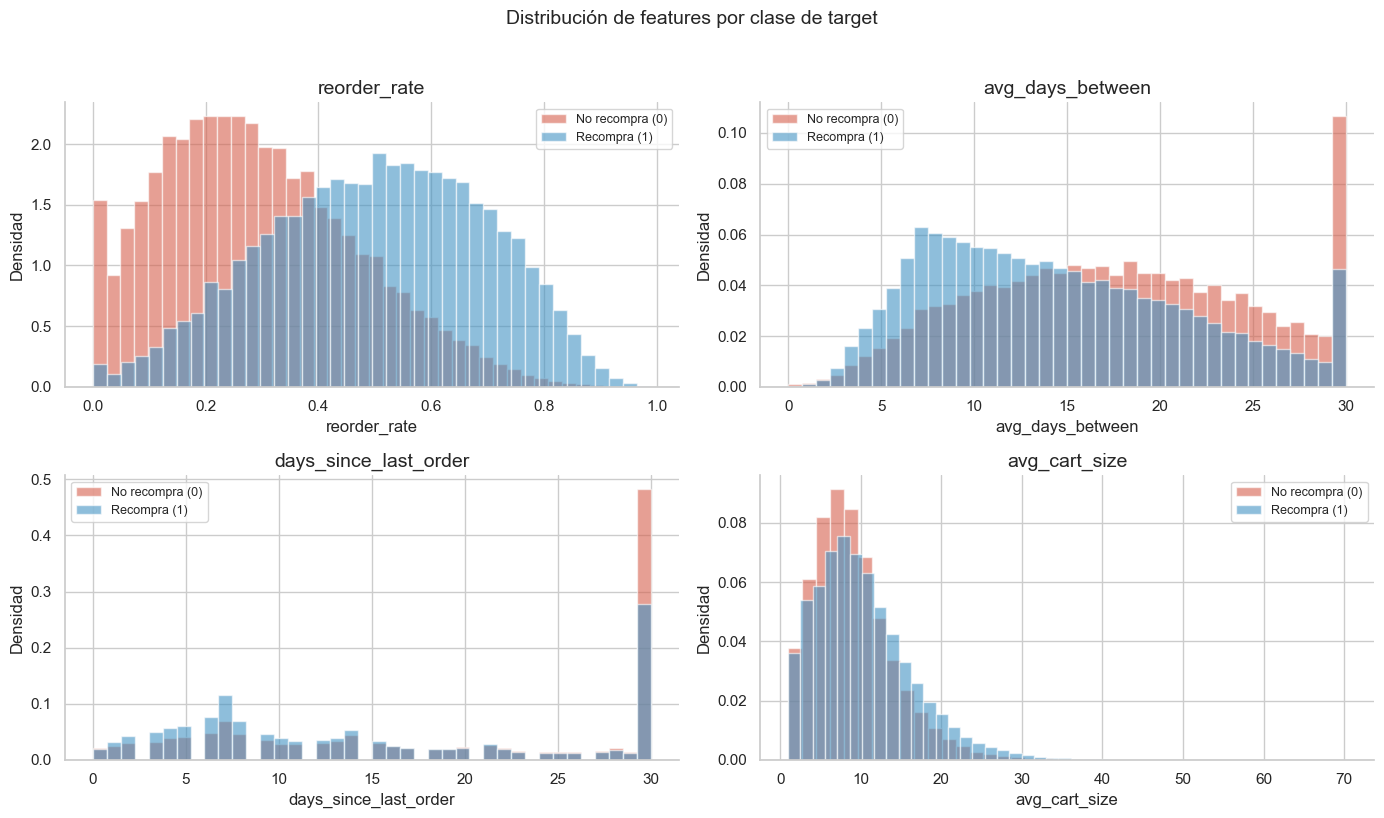

In [7]:
features_to_plot = ['reorder_rate', 'avg_days_between', 
                    'days_since_last_order', 'avg_cart_size']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, feature in zip(axes, features_to_plot):
    for target_val, label, color in [(0, 'No recompra (0)', '#d6604d'), 
                                      (1, 'Recompra (1)', '#4393c3')]:
        subset = df_model[df_model['target'] == target_val][feature]
        ax.hist(subset, bins=40, alpha=0.6, label=label, 
                color=color, density=True)
    
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de features por clase de target', 
             fontsize=14, y=1.02)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'feature_distributions.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusiones

El dataset final contiene 131.209 usuarios con 10 features de 
comportamiento y un target binario balanceado (66.65% / 33.35%).

Las features con mayor poder discriminatorio anticipado son 
`reorder_rate` y `days_since_last_order`. `avg_cart_size` muestra 
baja separación entre clases.

El dataset se exporta como CSV para consumo directo en el notebook 
de modelado.

In [8]:
output_path = os.path.join(OUTPUTS_DIR, 'instacart_features.csv')
df_model.to_csv(output_path, index=False)

print(f"Dataset guardado en: {output_path}")
print(f"Shape: {df_model.shape}")
print(f"\nColumnas:")
print(df_model.columns.tolist())

Dataset guardado en: ../outputs/instacart_features.csv
Shape: (131209, 12)

Columnas:
['user_id', 'total_orders', 'total_items', 'distinct_products', 'reorder_rate', 'avg_days_between', 'std_days_between', 'most_frequent_dow', 'most_frequent_hour', 'avg_cart_size', 'days_since_last_order', 'target']
